<a href="https://colab.research.google.com/github/lintaoye1388/EE631-ADC/blob/main/HW2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HW2

## Q3

Analyzing 490 kHz signal with Hann Window...


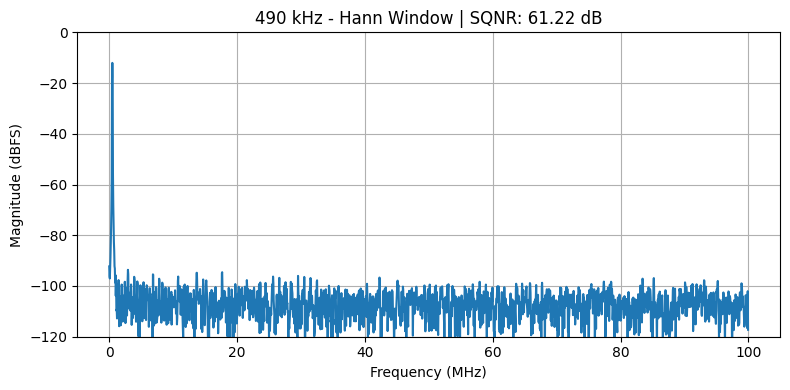

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy.signal.windows import blackman, hann, kaiser, hamming

# ==========================================
# 1. System Parameters
# ==========================================
Fs = 200e6          # Sampling rate = 200 MS/s
N_bits = 10         # 10-bit ADC
V_FS = 1.0          # Full-scale voltage (1V peak-to-peak)
N_samples = 4096    # Number of samples (Power of 2 for efficient FFT)

# Test Frequencies
f_in_low = 490e3    # 490 KHz
f_in_high = 95e6    # 95 MHz near Nyquist

# ==========================================
# 2. Ideal ADC Quantization Model
# ==========================================
def ideal_adc(vin, n_bits, v_fs):
    """
    Simulates an ideal N-bit ADC.
    """
    lsb = v_fs / (2**n_bits)

    # Quantize the input signal
    quantized_signal = np.round(vin / lsb) * lsb

    # Clip to maximum and minimum ADC bounds
    max_val = (v_fs / 2) - lsb
    min_val = -(v_fs / 2)
    quantized_signal = np.clip(quantized_signal, min_val, max_val)

    return quantized_signal

# ==========================================
# 3. FFT and SQNR Calculation
# ==========================================
def analyze_spectrum(signal, Fs, window_array=None, title="Spectrum"):
    """
    Applies a window, computes the FFT, calculates SQNR, and plots the spectrum.
    """
    N = len(signal)

    # Apply window if provided, else use rectangular (no window)
    if window_array is not None:
        signal = signal * window_array
        # Window correction factor to maintain amplitude
        coherent_gain = np.sum(window_array) / N
    else:
        coherent_gain = 1.0

    # Compute FFT
    spectrum = fft(signal) / (N * coherent_gain)
    spectrum_mag = np.abs(spectrum)[:N//2]
    freqs = fftfreq(N, 1/Fs)[:N//2]

    # Convert to dBFS (Decibels relative to Full Scale)
    # Adding a tiny value to avoid log10(0)
    spectrum_db = 20 * np.log10(spectrum_mag + 1e-12)

    # --- SQNR Calculation ---
    # --- Corrected SQNR Calculation ---
    # Find the peak signal bin (excluding DC component at index 0)
    signal_bin = np.argmax(spectrum_mag[1:]) + 1

    # Define how many bins around the peak contain the smeared signal energy
    # Hann/Hamming usually need +/- 3. Blackman/Kaiser might need +/- 5 or more.
    smear_width = 5

    # Define the range of bins that belong to the signal
    sig_start = max(1, signal_bin - smear_width)
    sig_end = min(len(spectrum_mag), signal_bin + smear_width + 1)

    # Sum the power across the entire main lobe for the true signal power
    signal_power = np.sum(spectrum_mag[sig_start:sig_end]**2)

    # Total power (excluding DC at bin 0)
    total_power = np.sum(spectrum_mag[1:]**2)

    # Noise power is whatever is left over outside the signal's main lobe
    noise_power = total_power - signal_power

    sqnr = 10 * np.log10(signal_power / noise_power)

    # Plotting
    plt.figure(figsize=(8, 4))
    plt.plot(freqs / 1e6, spectrum_db)
    plt.title(f"{title} | SQNR: {sqnr:.2f} dB")
    plt.xlabel("Frequency (MHz)")
    plt.ylabel("Magnitude (dBFS)")
    plt.grid(True)
    plt.ylim(-120, 0)
    plt.tight_layout()
    plt.show()

    #return sqnr

# ==========================================
# 4. Running the Simulation (Part A & B)
# ==========================================
# Create time vector
t = np.arange(N_samples) / Fs

# Generate an ideal sine wave (Full scale = 1Vpp -> Amplitude = 0.5V)
V_in_low = 0.5 * np.sin(2 * np.pi * f_in_low * t)
V_in_high = 0.5 * np.sin(2 * np.pi * f_in_high * t)
# Pass through the ideal ADC
V_out_low = ideal_adc(V_in_low, N_bits, V_FS)
V_out_high = ideal_adc(V_in_high, N_bits, V_FS)
# Generate Windows
win_hann = hann(N_samples)
win_blackman = blackman(N_samples)
win_hamming = hamming(N_samples)
win_kaiser = kaiser(N_samples, beta=14) # Beta determines sidelobe attenuation

# Analyze (Example using Hann Window for the 490 KHz signal)
print("Analyzing 490 kHz signal with Hann Window...")
analyze_spectrum(V_out_low, Fs, window_array=win_hann, title="490 kHz - Hann Window")


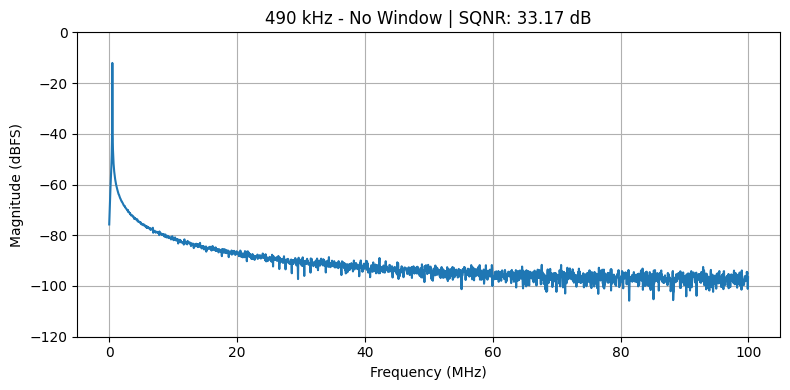

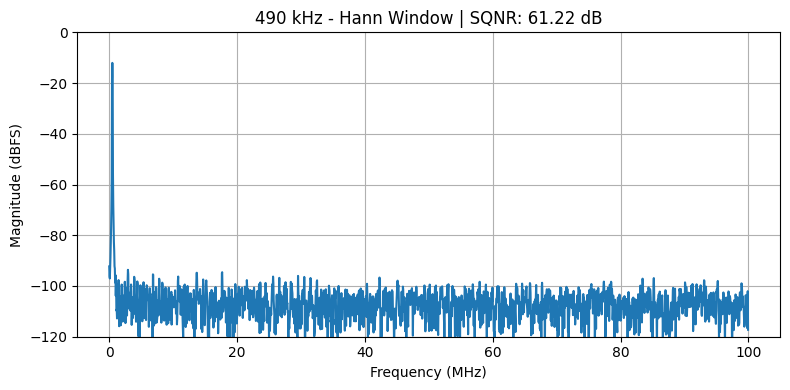

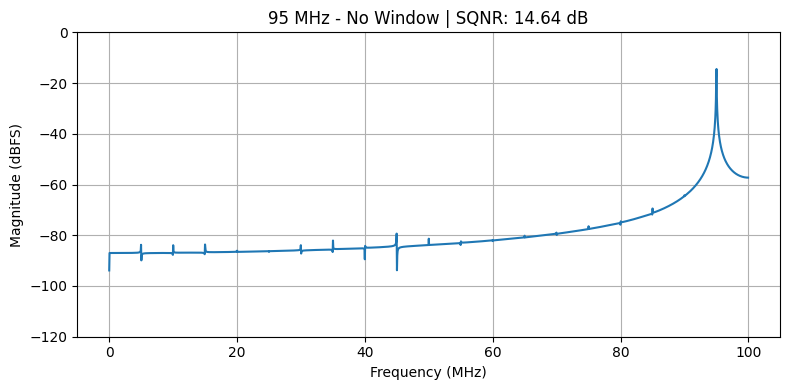

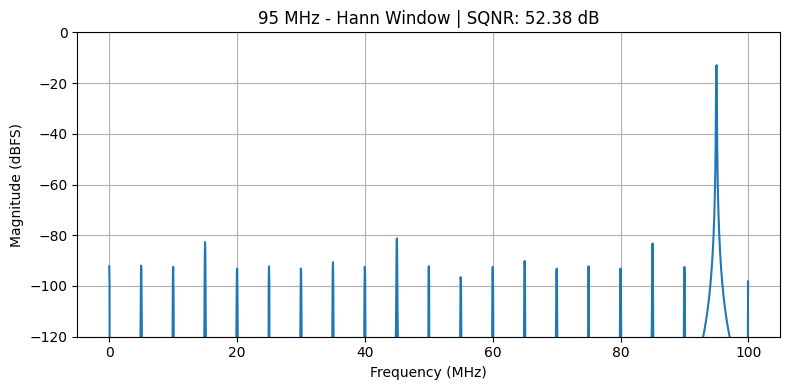

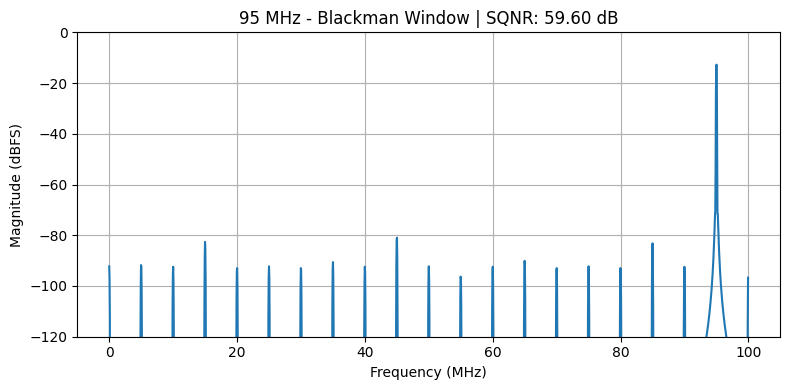

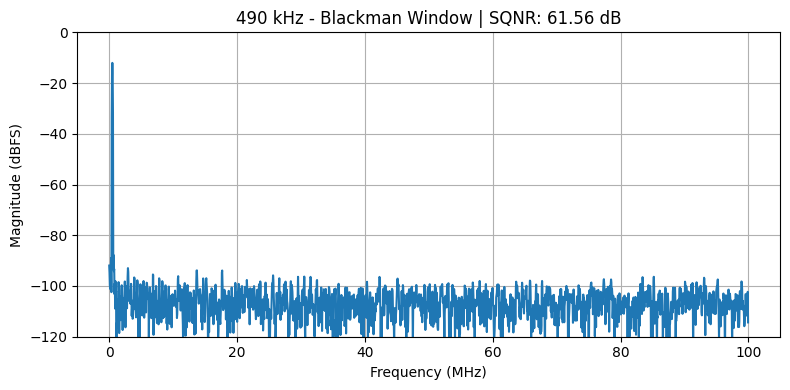

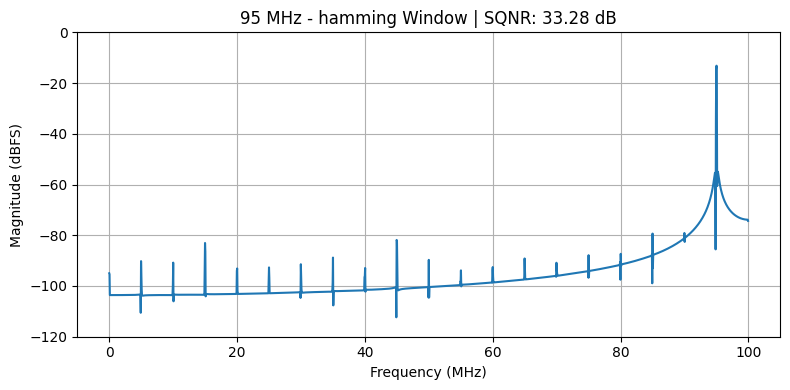

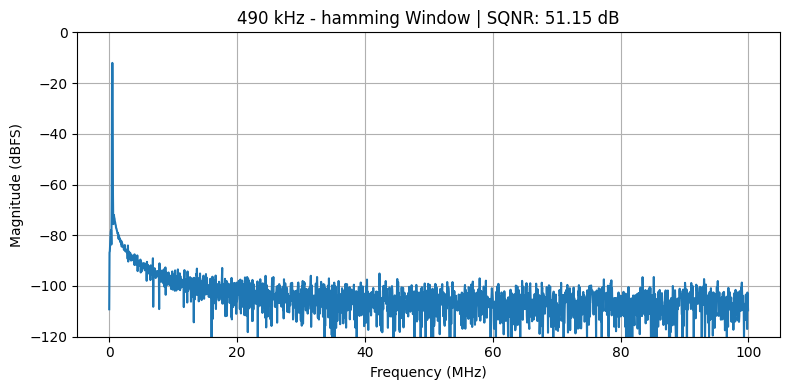

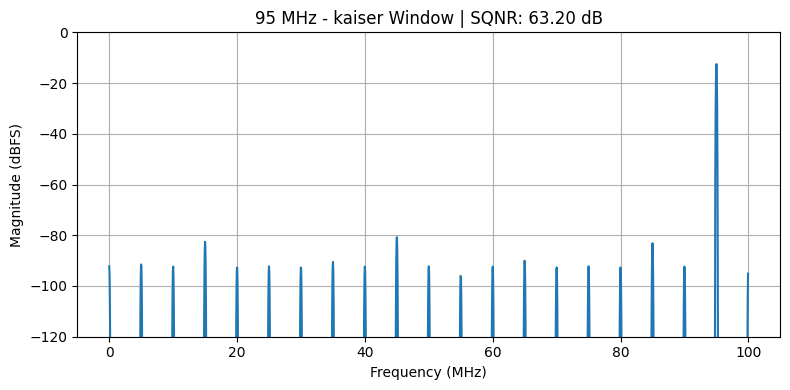

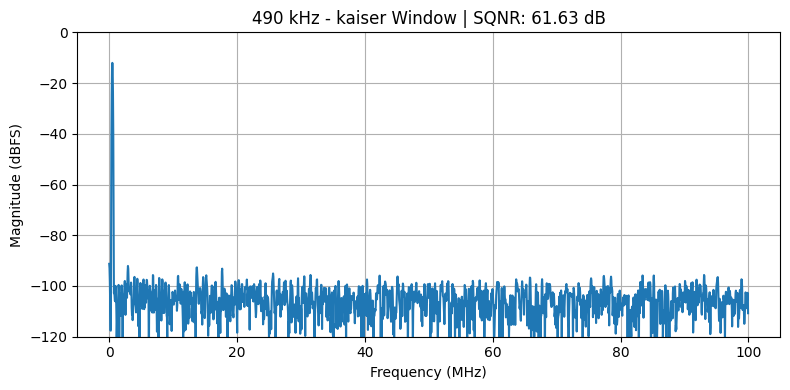

In [ ]:
analyze_spectrum(V_out_low, Fs, window_array=None, title="490 kHz - No Window")
analyze_spectrum(V_out_low, Fs, window_array=win_hann, title="490 kHz - Hann Window")
analyze_spectrum(V_out_high, Fs, window_array=None, title="95 MHz - No Window")
analyze_spectrum(V_out_high, Fs, window_array=win_hann, title="95 MHz - Hann Window")
analyze_spectrum(V_out_high, Fs, window_array=win_blackman, title="95 MHz - Blackman Window")
analyze_spectrum(V_out_low, Fs, window_array=win_blackman, title="490 kHz - Blackman Window")
analyze_spectrum(V_out_high, Fs, window_array=win_hamming, title="95 MHz - hamming Window")
analyze_spectrum(V_out_low, Fs, window_array=win_hamming, title="490 kHz - hamming Window")
analyze_spectrum(V_out_high, Fs, window_array=win_kaiser, title="95 MHz - kaiser Window")
analyze_spectrum(V_out_low, Fs, window_array=win_kaiser, title="490 kHz - kaiser Window")

In [ ]:
import numpy as np

# System Parameters
Fs = 200e6          # 200 MS/s
N_samples = 4096    # Number of samples
target_f1 = 490e3   # Target near 490 kHz
target_f2 = 95e6    # Target near 95 MHz

def is_prime(n):
    """Helper function to check if a number is prime."""
    if n <= 1:
        return False
    if n <= 3:
        return True
    if n % 2 == 0 or n % 3 == 0:
        return False
    i = 5
    while i * i <= n:
        if n % i == 0 or n % (i + 2) == 0:
            return False
        i += 6
    return True

def find_nearest_prime(n):
    """Finds the nearest prime number to a given integer."""
    n = int(round(n))
    if n <= 2: return 2

    # Check numbers moving outwards from n
    offset = 0
    while True:
        if is_prime(n + offset):
            return n + offset
        if is_prime(n - offset):
            return n - offset
        offset += 1

def calculate_coherent_fin(target_f, Fs, N):
    """Calculates the exact coherent frequency nearest to the target."""
    # 1. Calculate the ideal number of cycles (M_ideal)
    M_ideal = (target_f * N) / Fs

    # 2. Find the closest prime integer for M
    M_prime = find_nearest_prime(M_ideal)

    # 3. Calculate the exact coherent Fin
    Fin_coherent = (M_prime / N) * Fs

    return M_prime, Fin_coherent

# --- Run the calculations ---
M1, Fin1 = calculate_coherent_fin(target_f1, Fs, N_samples)
M2, Fin2 = calculate_coherent_fin(target_f2, Fs, N_samples)

print(f"--- Low Frequency Target: {target_f1 / 1e3} kHz ---")
print(f"Ideal cycles (M): {(target_f1 * N_samples) / Fs:.4f}")
print(f"Chosen Prime cycles (M): {M1}")
print(f"Exact Coherent Fin: {Fin1 / 1e3:.4f} kHz\n")

print(f"--- High Frequency Target: {target_f2 / 1e6} MHz ---")
print(f"Ideal cycles (M): {(target_f2 * N_samples) / Fs:.4f}")
print(f"Chosen Prime cycles (M): {M2}")
print(f"Exact Coherent Fin: {Fin2 / 1e6:.4f} MHz")

--- Low Frequency Target: 490.0 kHz ---
Ideal cycles (M): 10.0352
Chosen Prime cycles (M): 11
Exact Coherent Fin: 537.1094 kHz

--- High Frequency Target: 95.0 MHz ---
Ideal cycles (M): 1945.6000
Chosen Prime cycles (M): 1949
Exact Coherent Fin: 95.1660 MHz


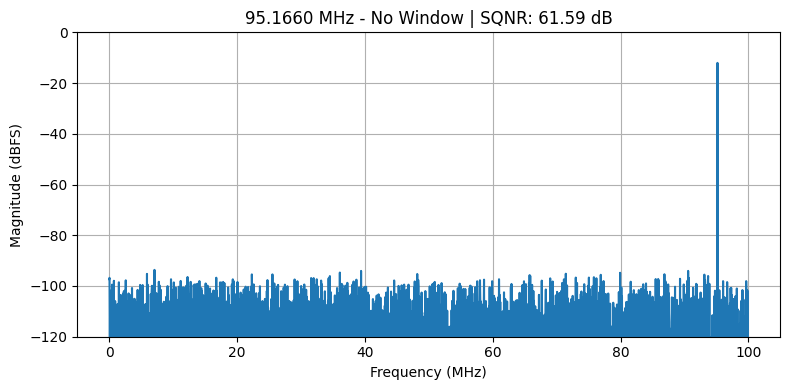

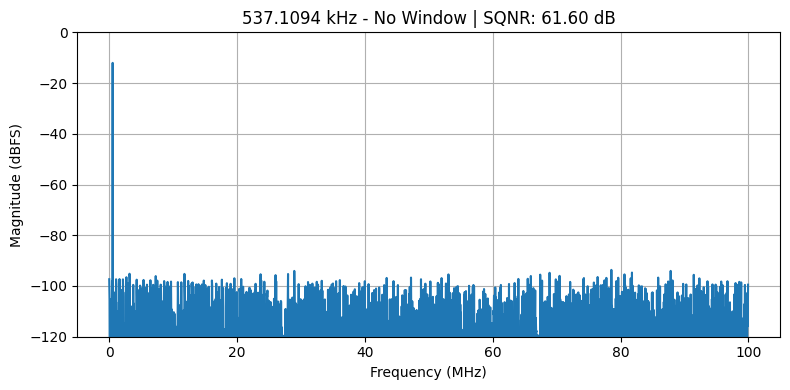

In [ ]:
# Generate an ideal sine wave (Full scale = 1Vpp -> Amplitude = 0.5V)
V_in_low_ww = 0.5 * np.sin(2 * np.pi * Fin1 * t)
V_in_high_ww = 0.5 * np.sin(2 * np.pi * Fin2 * t)
# Pass through the ideal ADC
V_out_low_ww = ideal_adc(V_in_low_ww, N_bits, V_FS)
V_out_high_ww = ideal_adc(V_in_high_ww, N_bits, V_FS)

analyze_spectrum(V_out_high_ww, Fs, window_array=None, title=f"{Fin2 / 1e6:.4f} MHz - No Window")
analyze_spectrum(V_out_low_ww, Fs, window_array=None, title=f"{Fin1 / 1e3:.4f} kHz - No Window")

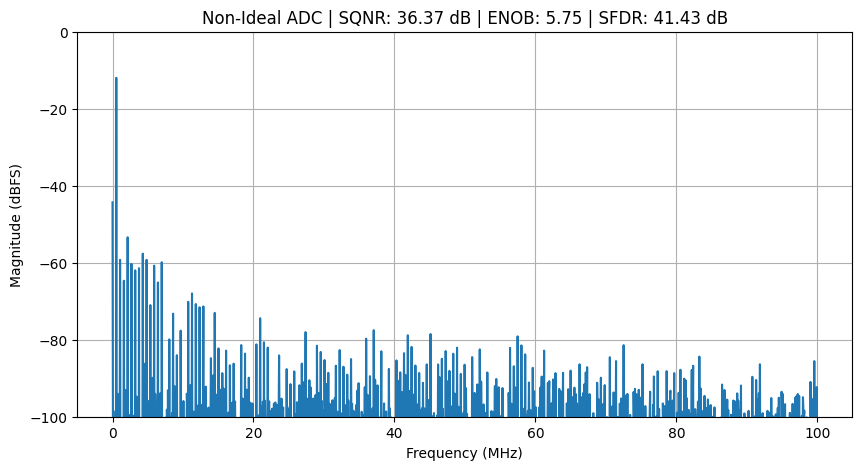

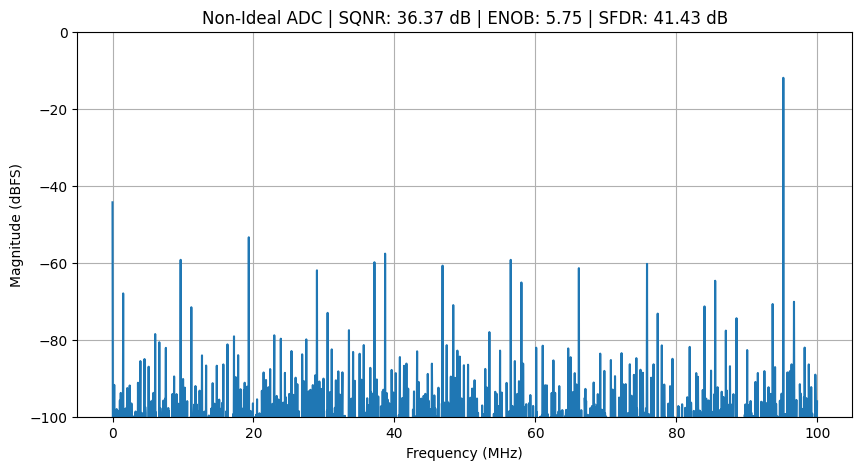

(np.float64(36.36594693014894),
 np.float64(5.7484961677988275),
 np.float64(41.425387876386736))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

# ==========================================
# 1. System Parameters (Coherent Setup)
# ==========================================
Fs = 200e6          # 200 MS/s
N_bits = 10         # 10-bit ADC
V_FS = 1.0          # 1V Full Scale
N_samples = 4096

# Using the Coherent frequency calculated from part (c) for 490 kHz
# M = 11 (Prime), N = 4096
f_in_coherent = (11 / 4096) * Fs

# ==========================================
# 2. Non-Ideal ADC Model (DNL Generation)
# ==========================================
def non_ideal_adc(vin, n_bits, v_fs):
    num_codes = 2**n_bits
    lsb = v_fs / num_codes

    # 1. Generate DNL: Uniformly distributed between -1 and +1 LSB
    # We need (num_codes - 1) transition thresholds
    np.random.seed(42) # Seed for repeatable results
    dnl = np.random.uniform(-1, 1, size=num_codes - 1)

    # 2. Calculate actual step widths
    # An ideal step is 1 * LSB. The actual step is (1 + DNL) * LSB
    step_widths = lsb * (1 + dnl)

    # 3. Create the transition thresholds (Cumulative sum of widths)
    # Start at the bottom of the voltage range
    transitions = -(v_fs / 2) + np.cumsum(step_widths)

    # 4. Digitize the input: Find which bin each voltage sample falls into
    # np.searchsorted behaves like an array of hardware comparators
    digital_codes = np.searchsorted(transitions, vin)

    # 5. Map the digital codes back to ideal analog voltages
    # (Because the DAC reading this data assumes the ADC was ideal)
    vout = -(v_fs / 2) + (digital_codes * lsb) + (lsb / 2)

    # Clip to max/min to avoid overflow
    max_val = (v_fs / 2) - (lsb / 2)
    min_val = -(v_fs / 2) + (lsb / 2)
    vout = np.clip(vout, min_val, max_val)

    return vout

# ==========================================
# 3. Metrics Calculation: SQNR, ENOB, SFDR
# ==========================================
def analyze_metrics(signal, Fs):
    N = len(signal)

    # FFT (No window needed due to coherent sampling)
    spectrum = fft(signal) / N
    spectrum_mag = np.abs(spectrum)[:N//2]
    freqs = fftfreq(N, 1/Fs)[:N//2]

    # Find signal bin
    signal_bin = np.argmax(spectrum_mag[1:]) + 1
    signal_power = spectrum_mag[signal_bin]**2

    # Calculate Total Noise Power (excluding DC and Signal)
    total_power = np.sum(spectrum_mag[1:]**2)
    noise_and_distortion_power = total_power - signal_power

    # --- 1. SQNR (or SINAD in this case) ---
    sqnr = 10 * np.log10(signal_power / noise_and_distortion_power)

    # --- 2. ENOB (Effective Number of Bits) ---
    enob = (sqnr - 1.76) / 6.02

    # --- 3. SFDR (Spurious-Free Dynamic Range) ---
    # Find the largest spur (highest peak that IS NOT the signal)
    spectrum_no_signal = np.copy(spectrum_mag)
    spectrum_no_signal[signal_bin] = 0 # Remove the signal spike
    spectrum_no_signal[0] = 0          # Remove DC

    spur_bin = np.argmax(spectrum_no_signal)
    max_spur_power = spectrum_no_signal[spur_bin]**2

    sfdr = 10 * np.log10(signal_power / max_spur_power)

    # Plotting to see the harmonics
    spectrum_db = 20 * np.log10(spectrum_mag + 1e-12)
    plt.figure(figsize=(10, 5))
    plt.plot(freqs / 1e6, spectrum_db)
    plt.title(f"Non-Ideal ADC | SQNR: {sqnr:.2f} dB | ENOB: {enob:.2f} | SFDR: {sfdr:.2f} dB")
    plt.xlabel("Frequency (MHz)")
    plt.ylabel("Magnitude (dBFS)")
    plt.ylim(-100, 0)
    plt.grid(True)
    plt.show()

    return sqnr, enob, sfdr

# ==========================================
# 4. Run Simulation
# ==========================================
t = np.arange(N_samples) / Fs
V_in_coherent = 0.5 * np.sin(2 * np.pi * f_in_coherent * t)
V_in_coherent_high = 0.5 * np.sin(2 * np.pi * Fin2 * t)
# Pass through DNL-affected ADC
V_out_dnl = non_ideal_adc(V_in_coherent, N_bits, V_FS)
V_out_dnl_high = non_ideal_adc(V_in_coherent_high, N_bits, V_FS)
# Analyze
sqnr, enob, sfdr = analyze_metrics(V_out_dnl, Fs)
analyze_metrics(V_out_dnl_high, Fs)

In [ ]:
def analyze_spectrum(signal, Fs, window_array=None, title="Spectrum"):
    """
    Applies a window, computes the FFT, calculates SQNR, ENOB, SFDR, and plots the spectrum.
    """
    N = len(signal)

    # Apply window if provided, else use rectangular (no window)
    if window_array is not None:
        signal = signal * window_array
        # Window correction factor to maintain amplitude
        coherent_gain = np.sum(window_array) / N
    else:
        coherent_gain = 1.0

    # Compute FFT
    spectrum = fft(signal) / (N * coherent_gain)
    spectrum_mag = np.abs(spectrum)[:N//2]
    freqs = fftfreq(N, 1/Fs)[:N//2]

    # Convert to dBFS (Decibels relative to Full Scale)
    # Adding a tiny value to avoid log10(0)
    spectrum_db = 20 * np.log10(spectrum_mag + 1e-12)

    # --- SQNR Calculation ---
    # Find the peak signal bin (excluding DC component at index 0)
    signal_bin = np.argmax(spectrum_mag[1:]) + 1

    # Define how many bins around the peak contain the smeared signal energy
    # Hann/Hamming usually need +/- 3. Blackman/Kaiser might need +/- 5 or more.
    smear_width = 5

    # Define the range of bins that belong to the signal
    sig_start = max(1, signal_bin - smear_width)
    sig_end = min(len(spectrum_mag), signal_bin + smear_width + 1)

    # Sum the power across the entire main lobe for the true signal power
    signal_power = np.sum(spectrum_mag[sig_start:sig_end]**2)

    # Total power (excluding DC at bin 0)
    total_power = np.sum(spectrum_mag[1:]**2)

    # Noise power is whatever is left over outside the signal's main lobe
    noise_power = total_power - signal_power

    sqnr = 10 * np.log10(signal_power / noise_power)

    # --- ENOB Calculation ---
    # Derived from the ideal ADC equation: SQNR = 6.02 * N + 1.76
    enob = (sqnr - 1.76) / 6.02

    # --- SFDR Calculation ---
    # Copy the magnitude spectrum so we can remove the signal and DC
    # without destroying the original data for plotting
    spectrum_no_signal = np.copy(spectrum_mag)

    # Zero out the DC component
    spectrum_no_signal[0] = 0

    # Zero out the entire signal main lobe (using the same smear bounds)
    spectrum_no_signal[sig_start:sig_end] = 0

    # Find the highest remaining peak (the largest spur)
    spur_bin = np.argmax(spectrum_no_signal)
    max_spur_power = spectrum_no_signal[spur_bin]**2

    # Calculate SFDR (Ratio of Signal Power to Max Spur Power)
    # Adding 1e-12 to avoid division by zero if the noise floor is perfectly 0
    sfdr = 10 * np.log10(signal_power / (max_spur_power + 1e-12))

    # Plotting
    plt.figure(figsize=(10, 5))
    plt.plot(freqs / 1e6, spectrum_db)
    plt.title(f"{title} | SQNR: {sqnr:.2f} dB | ENOB: {enob:.2f} bits | SFDR: {sfdr:.2f} dBc")
    plt.xlabel("Frequency (MHz)")
    plt.ylabel("Magnitude (dBFS)")
    plt.grid(True)
    plt.ylim(-120, 0)
    plt.tight_layout()
    plt.show()

    return sqnr, enob, sfdr

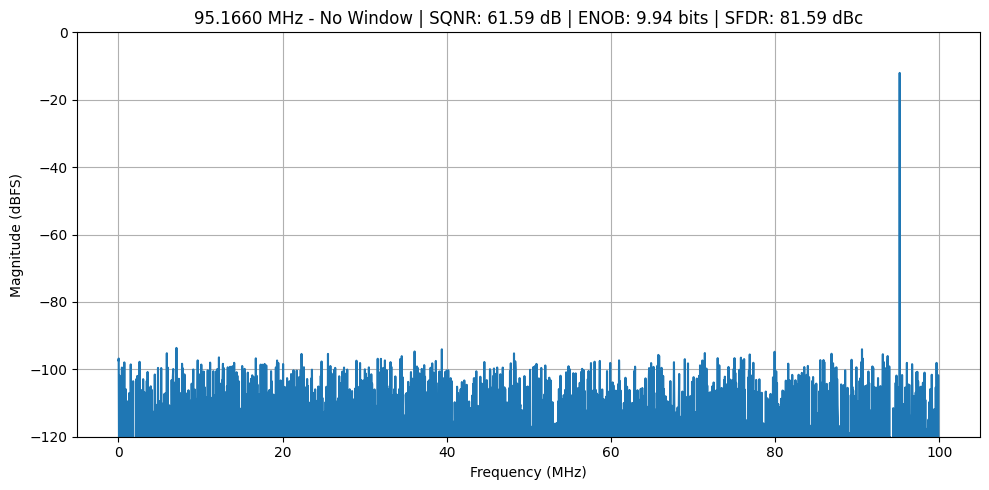

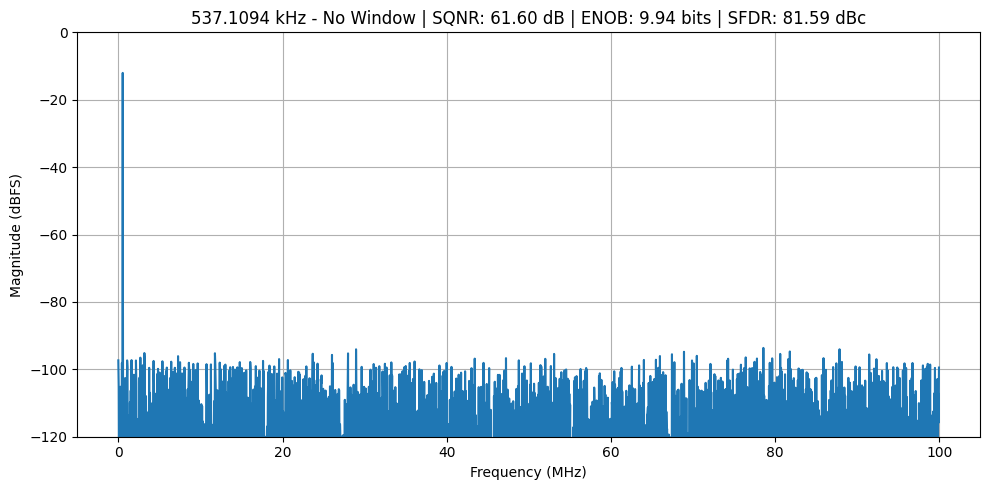

(np.float64(61.601740245422846),
 np.float64(9.940488412860939),
 np.float64(81.59465146773383))

In [ ]:
analyze_spectrum(V_out_high_ww, Fs, window_array=None, title=f"{Fin2 / 1e6:.4f} MHz - No Window")
analyze_spectrum(V_out_low_ww, Fs, window_array=None, title=f"{Fin1 / 1e3:.4f} kHz - No Window")

--- ADC with DNL and Missing Code (100) ---
SQNR: 36.35 dB
ENOB: 5.75 bits
SFDR: 41.38 dBc



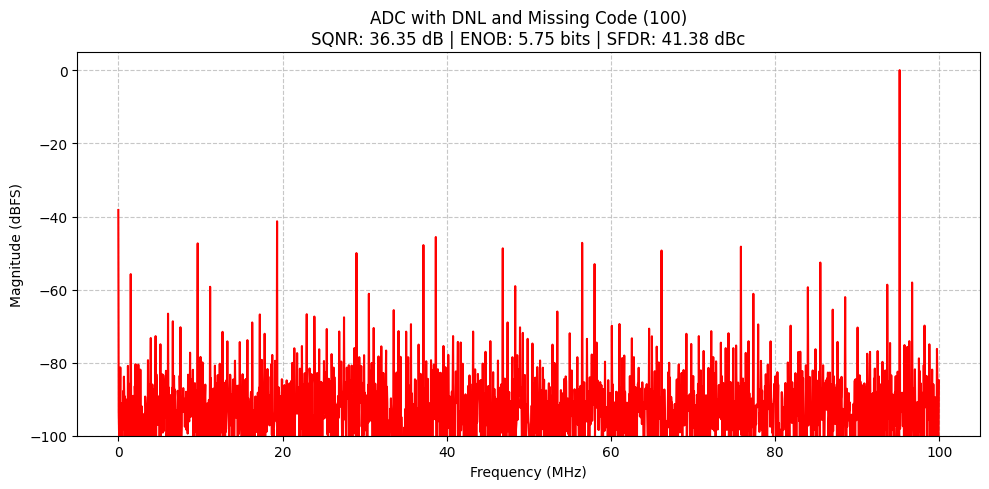

--- ADC with DNL and Missing Code (100) ---
SQNR: 36.35 dB
ENOB: 5.75 bits
SFDR: 41.38 dBc



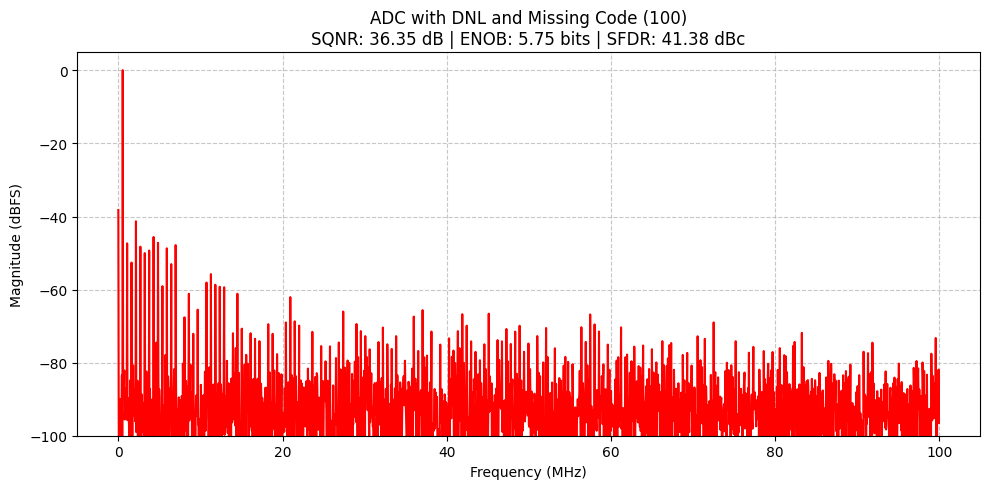

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

# ==========================================
# 1. System Parameters
# ==========================================
Fs = 200e6          # 200 MS/s
N_bits = 10         # 10-bit ADC
V_FS = 1.0          # 1V Full Scale
N_samples = 4096

# Coherent frequency from part (c) for ~490 kHz (M=11)
f_in_coherent = (11 / 4096) * Fs

# ==========================================
# 2. ADC Model with DNL & Missing Code
# ==========================================
def adc_missing_code(vin, n_bits, v_fs, missing_code_idx=100):
    num_codes = 2**n_bits
    lsb = v_fs / num_codes

    # Generate Uniform DNL between -1 and +1 LSB for all codes
    np.random.seed(42) # Seed for repeatable results
    dnl = np.random.uniform(-1, 1, size=num_codes)

    # FORCE THE MISSING CODE
    # Setting DNL to -1 makes the step width exactly 0 LSB.
    dnl[missing_code_idx] = -1.0

    # Calculate step widths
    step_widths = lsb * (1 + dnl)

    # Create the transition thresholds
    # We only need num_codes - 1 transitions
    transitions = -(v_fs / 2) + np.cumsum(step_widths[:-1])

    # Digitize the input
    digital_codes = np.searchsorted(transitions, vin)

    # Map digital codes back to ideal analog voltages
    vout = -(v_fs / 2) + (digital_codes * lsb) + (lsb / 2)

    # Clip to bounds
    max_val = (v_fs / 2) - (lsb / 2)
    min_val = -(v_fs / 2) + (lsb / 2)
    vout = np.clip(vout, min_val, max_val)

    return vout

# ==========================================
# 3. Analyze Spectrum & Metrics
# ==========================================
def analyze_spectrum(signal, Fs, title="Spectrum"):
    N = len(signal)

    # FFT (No window needed due to coherent sampling)
    spectrum = fft(signal) / N
    spectrum_mag = np.abs(spectrum)[:N//2]
    spectrum_mag[1:] = spectrum_mag[1:] * 2
    freqs = fftfreq(N, 1/Fs)[:N//2]

    spectrum_db = 20 * np.log10(spectrum_mag / 0.5 + 1e-12)

    # Find signal bin
    signal_bin = np.argmax(spectrum_mag[1:]) + 1
    signal_power = spectrum_mag[signal_bin]**2

    # Total noise power
    spectrum_no_signal = np.copy(spectrum_mag)
    spectrum_no_signal[signal_bin] = 0
    spectrum_no_signal[0] = 0

    noise_power = np.sum(spectrum_no_signal**2)

    # Metrics
    sqnr = 10 * np.log10(signal_power / noise_power)
    enob = (sqnr - 1.76) / 6.02

    spur_bin = np.argmax(spectrum_no_signal)
    max_spur_power = spectrum_no_signal[spur_bin]**2
    sfdr = 10 * np.log10(signal_power / (max_spur_power + 1e-12))

    print(f"--- {title} ---")
    print(f"SQNR: {sqnr:.2f} dB")
    print(f"ENOB: {enob:.2f} bits")
    print(f"SFDR: {sfdr:.2f} dBc\n")

    # Plotting
    plt.figure(figsize=(10, 5))
    plt.plot(freqs / 1e6, spectrum_db, color='r')
    plt.title(f"{title}\nSQNR: {sqnr:.2f} dB | ENOB: {enob:.2f} bits | SFDR: {sfdr:.2f} dBc")
    plt.xlabel("Frequency (MHz)")
    plt.ylabel("Magnitude (dBFS)")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.ylim(-100, 5)
    plt.tight_layout()
    plt.show()

# ==========================================
# 4. Run Simulation
# ==========================================
t = np.arange(N_samples) / Fs
V_in = 0.5 * np.sin(2 * np.pi * f_in_coherent * t)
V_in_high = 0.5 * np.sin(2 * np.pi * Fin2 * t)
# Pass through ADC with missing code 100
V_out_missing = adc_missing_code(V_in, N_bits, V_FS, missing_code_idx=100)
V_out_missing_high = adc_missing_code(V_in_high, N_bits, V_FS, missing_code_idx=100)

analyze_spectrum(V_out_missing_high, Fs, "ADC with DNL and Missing Code (100)")
analyze_spectrum(V_out_missing, Fs, "ADC with DNL and Missing Code (100)")

Running FFT Analysis...


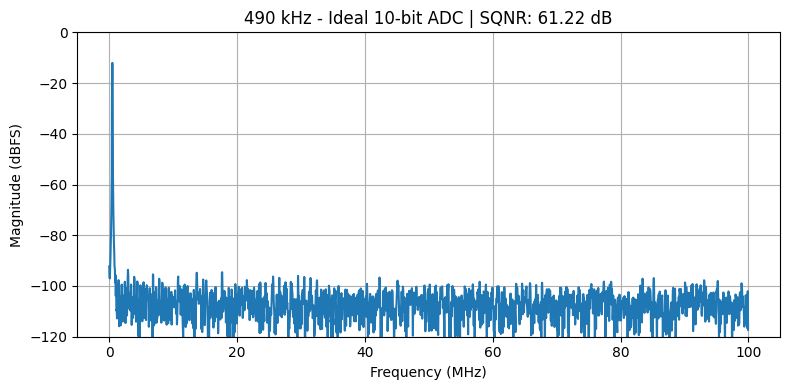

Running Sine Wave Histogram Analysis...


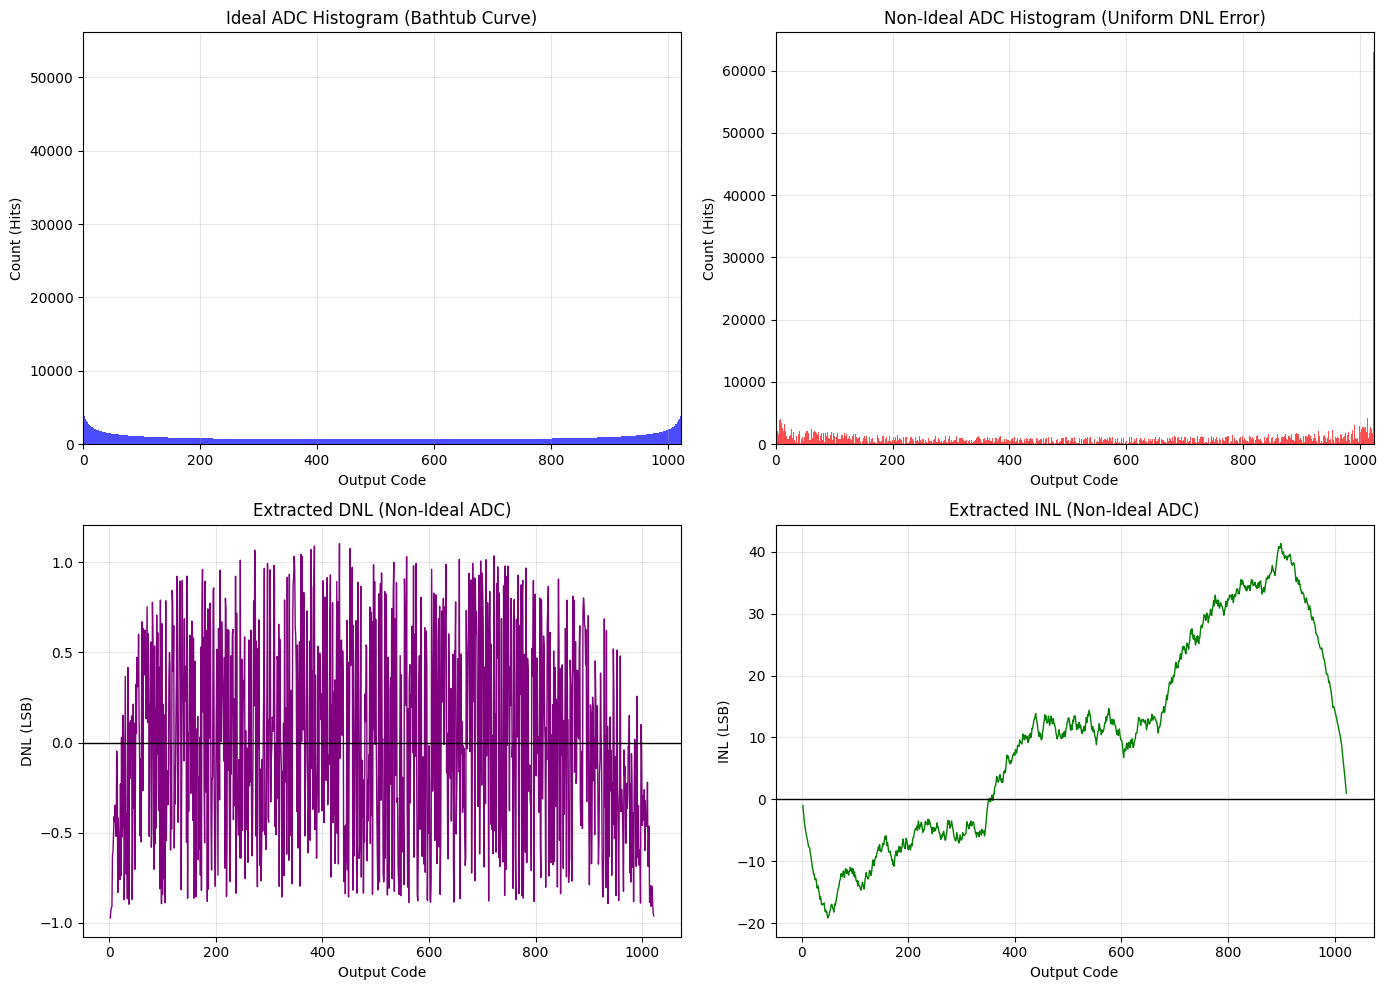

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy.signal.windows import blackman, hann, kaiser, hamming

# ==========================================
# 1. System Parameters
# ==========================================
Fs = 200e6          # Sampling rate = 200 MS/s
N_bits = 10         # 10-bit ADC
V_FS = 1.0          # Full-scale voltage (1V peak-to-peak)
N_codes = 2**N_bits # 1024 codes

# FFT Parameters
N_samples_fft = 4096
f_in_low = 490e3    # 490 KHz

# Histogram Parameters (Need many samples for 1024 bins)
N_samples_hist = 2**20  # ~1 Million samples
f_in_high = 95e6        # 95 MHz near Nyquist

# ==========================================
# 2. ADC Quantization Models
# ==========================================
def ideal_adc(vin, n_bits, v_fs):
    """
    Simulates an ideal N-bit ADC returning quantized voltages.
    """
    lsb = v_fs / (2**n_bits)
    quantized_signal = np.round(vin / lsb) * lsb

    max_val = (v_fs / 2) - lsb
    min_val = -(v_fs / 2)
    quantized_signal = np.clip(quantized_signal, min_val, max_val)
    return quantized_signal

def nonideal_adc_codes(vin, n_bits, v_fs):
    """
    Simulates a non-ideal N-bit ADC returning integer codes (0 to 2^N-1).
    Injects uniformly distributed DNL bounded within +/- 0.9 LSB.
    """
    n_codes = 2**n_bits
    lsb = v_fs / n_codes

    # Ideal transitions
    transitions_ideal = np.linspace(-(v_fs/2) + lsb, (v_fs/2) - lsb, n_codes - 1)

    # Inject DNL to code widths
    dnl = np.random.uniform(-0.9, 0.9, n_codes - 2)
    actual_widths = lsb * (1 + dnl)

    # Build non-ideal transitions
    transitions_nonideal = np.zeros(n_codes - 1)
    transitions_nonideal[0] = transitions_ideal[0]
    for i in range(1, n_codes - 1):
        transitions_nonideal[i] = transitions_nonideal[i-1] + actual_widths[i-1]

    # Quantize directly to integer codes (0 to 1023)
    codes = np.digitize(vin, transitions_nonideal)
    return codes

# Helper to convert ideal voltages to integer codes for histogram
def voltage_to_codes(v_quantized, n_bits, v_fs):
    min_val = -(v_fs / 2)
    lsb = v_fs / (2**n_bits)
    codes = np.round((v_quantized - min_val) / lsb).astype(int)
    return np.clip(codes, 0, (2**n_bits)-1)

# ==========================================
# 3. FFT and SQNR Calculation (Unchanged)
# ==========================================
def analyze_spectrum(signal, Fs, window_array=None, title="Spectrum"):
    N = len(signal)
    if window_array is not None:
        signal = signal * window_array
        coherent_gain = np.sum(window_array) / N
    else:
        coherent_gain = 1.0

    spectrum = fft(signal) / (N * coherent_gain)
    spectrum_mag = np.abs(spectrum)[:N//2]
    freqs = fftfreq(N, 1/Fs)[:N//2]
    spectrum_db = 20 * np.log10(spectrum_mag + 1e-12)

    signal_bin = np.argmax(spectrum_mag[1:]) + 1
    smear_width = 5
    sig_start = max(1, signal_bin - smear_width)
    sig_end = min(len(spectrum_mag), signal_bin + smear_width + 1)

    signal_power = np.sum(spectrum_mag[sig_start:sig_end]**2)
    total_power = np.sum(spectrum_mag[1:]**2)
    noise_power = total_power - signal_power
    sqnr = 10 * np.log10(signal_power / noise_power)

    plt.figure(figsize=(8, 4))
    plt.plot(freqs / 1e6, spectrum_db)
    plt.title(f"{title} | SQNR: {sqnr:.2f} dB")
    plt.xlabel("Frequency (MHz)")
    plt.ylabel("Magnitude (dBFS)")
    plt.grid(True)
    plt.ylim(-120, 0)
    plt.tight_layout()
    plt.show()

# ==========================================
# 4. Histogram Test Processing (New)
# ==========================================
def calculate_dnl_inl(codes, n_codes):
    """
    Calculates DNL and INL from an array of ADC output codes using the Sine Wave Histogram method.
    """
    # 1. Compute Histogram
    hist, _ = np.histogram(codes, bins=np.arange(n_codes + 1))

    # 2. Ignore first and last bins (they contain the overdrive accumulation)
    H = hist[1:-1]

    # 3. Cumulative histogram
    C = np.cumsum(H)
    Nt = C[-1] # Total valid hits

    # 4. Convert hits to transition voltages using Sine Wave PDF
    # Normalized amplitude A=1
    V_trans = -np.cos(np.pi * C / Nt)

    # 5. Calculate widths and LSB
    widths = np.diff(V_trans)
    LSB_est = (V_trans[-1] - V_trans[0]) / (n_codes - 2)

    # 6. DNL and INL calculation
    DNL = (widths / LSB_est) - 1
    INL = np.cumsum(DNL)

    return hist, DNL, INL

# ==========================================
# 5. Running the Simulations
# ==========================================

# --- PART A: FFT Simulation (From your original code) ---
t_fft = np.arange(N_samples_fft) / Fs
V_in_fft = 0.5 * np.sin(2 * np.pi * f_in_low * t_fft)
V_out_fft = ideal_adc(V_in_fft, N_bits, V_FS)
win_hann = hann(N_samples_fft)

print("Running FFT Analysis...")
analyze_spectrum(V_out_fft, Fs, window_array=win_hann, title="490 kHz - Ideal 10-bit ADC")


# --- PART B: Sine Wave Histogram Test ---
print("Running Sine Wave Histogram Analysis...")

# Coherent Sampling Setup for Histogram
# M must be an odd integer so it's mutually prime with N (which is a power of 2)
M = int(N_samples_hist * (f_in_high / Fs)) | 1
f_in_coherent = Fs * (M / N_samples_hist)

# Time vector and Overdriven Sine Wave (1% overdrive)
t_hist = np.arange(N_samples_hist) / Fs
amplitude_overdrive = (V_FS / 2) * 1.01
V_in_hist = amplitude_overdrive * np.sin(2 * np.pi * f_in_coherent * t_hist)

# 1. Test Ideal ADC
V_out_ideal = ideal_adc(V_in_hist, N_bits, V_FS)
codes_ideal = voltage_to_codes(V_out_ideal, N_bits, V_FS)
hist_ideal, dnl_ideal, inl_ideal = calculate_dnl_inl(codes_ideal, N_codes)

# 2. Test Non-Ideal ADC
codes_nonideal = nonideal_adc_codes(V_in_hist, N_bits, V_FS)
hist_nonideal, dnl_ni, inl_ni = calculate_dnl_inl(codes_nonideal, N_codes)

# ==========================================
# 6. Plotting Histogram Results
# ==========================================
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Ideal Histogram
axs[0, 0].bar(np.arange(N_codes), hist_ideal, width=1, color='blue', alpha=0.7)
axs[0, 0].set_title('Ideal ADC Histogram (Bathtub Curve)')
axs[0, 0].set_xlabel('Output Code')
axs[0, 0].set_ylabel('Count (Hits)')
axs[0, 0].set_xlim(0, N_codes-1)
axs[0, 0].grid(True, alpha=0.3)

# Non-Ideal Histogram
axs[0, 1].bar(np.arange(N_codes), hist_nonideal, width=1, color='red', alpha=0.7)
axs[0, 1].set_title('Non-Ideal ADC Histogram (Uniform DNL Error)')
axs[0, 1].set_xlabel('Output Code')
axs[0, 1].set_ylabel('Count (Hits)')
axs[0, 1].set_xlim(0, N_codes-1)
axs[0, 1].grid(True, alpha=0.3)

# Create the correctly sized X-axis array for the extracted codes (Length: 1021)
codes_x = np.arange(2, N_codes - 1)

# Non-Ideal DNL
axs[1, 0].plot(codes_x, dnl_ni, color='purple', linewidth=1)
axs[1, 0].set_title('Extracted DNL (Non-Ideal ADC)')
axs[1, 0].set_xlabel('Output Code')
axs[1, 0].set_ylabel('DNL (LSB)')
axs[1, 0].axhline(0, color='black', linewidth=1)
axs[1, 0].grid(True, alpha=0.3)

# Non-Ideal INL
axs[1, 1].plot(codes_x, inl_ni, color='green', linewidth=1)
axs[1, 1].set_title('Extracted INL (Non-Ideal ADC)')
axs[1, 1].set_xlabel('Output Code')
axs[1, 1].set_ylabel('INL (LSB)')
axs[1, 1].axhline(0, color='black', linewidth=1)
axs[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()